# Nonnegative data — `projection="weighted-nmf"`

Some data is **nonnegative and additive**: TF-IDF / bag-of-words counts, event tallies, spectrogram
magnitudes, pixel or colour histograms. There each object is a *sum of parts*, and a **nonnegative
matrix factorization** `X ≈ W H` (`W, H ≥ 0`) is the natural representation — the parts `H` are
interpretable, and the per-object codes `W` are what you cluster.

Running NMF over all `N` rows defeats BETULA's compression (it is `O(N·d·r)` and holds an `N×r` code
matrix). **`projection="weighted-nmf"`** factorizes the `M ≪ N` leaf **centroids** instead: by
König-Huygens the weighted-centroid NMF equals the full-data one up to the within-leaf scatter
constant, so NMF runs at BETULA scale and bounded memory, and any head then clusters the codes.

All numbers are computed live. See [`docs/MATH.md`](../docs/MATH.md#cf-weighted-nmf-for-nonnegative-data).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import adjusted_rand_score as ari

import betula_cluster

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})


def topic_corpus(n_per, d, k, seed):
    """`k` latent nonnegative "topics"; each document is a nonnegative mixture dominated by one."""
    rng = np.random.default_rng(seed)
    parts = np.abs(rng.normal(size=(k, d))) * (rng.random((k, d)) < 0.35)  # sparse nonneg parts
    xs, ys = [], []
    for c in range(k):
        w = rng.random((n_per, k)) * 0.15  # small cross-topic leakage
        w[:, c] += 1.0 + rng.random(n_per)  # dominant topic
        xs.append(w @ parts + 0.02 * rng.random((n_per, d)))
        ys += [c] * n_per
    return np.ascontiguousarray(np.vstack(xs)), np.array(ys), parts


d, k = 50, 4
X, y, parts = topic_corpus(600, d, k, seed=0)
print(f"corpus: {X.shape[0]} documents × {d} nonnegative features, {k} latent topics")

corpus: 2400 documents × 50 nonnegative features, 4 latent topics


## The data — nonnegative, additive, overlapping

Each row is a nonnegative feature vector; documents of the same topic share a dominant set of active
features, but every document mixes in a little of the others. Raw Euclidean k-means on the sparse
high-`d` counts sees mostly magnitude, not topic.

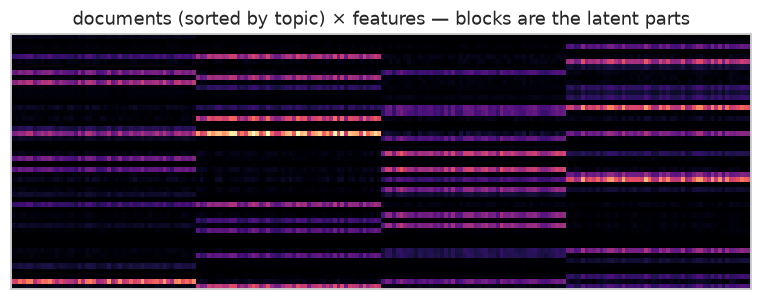

In [2]:
fig, ax = plt.subplots(figsize=(7, 2.8))
order = np.argsort(y)
ax.imshow(X[order][::12].T, aspect="auto", cmap="magma")
ax.set(title="documents (sorted by topic) × features — blocks are the latent parts", xticks=[], yticks=[])
fig.tight_layout()
plt.show()

## Cluster it — reduce over the leaves, then k-means

`projection="weighted-nmf"` factorizes the leaf centroids into `projection_dim` nonnegative codes and
clusters those. We score it against raw k-means on the full counts and a diagonal GMM.

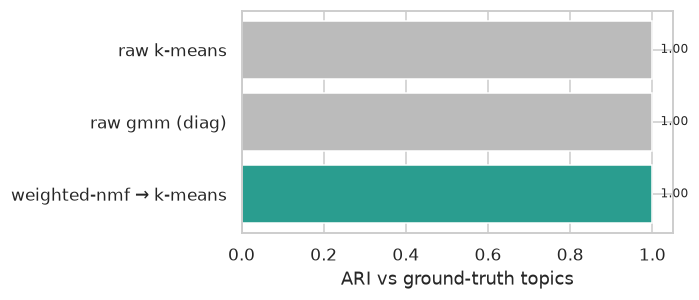

{'raw k-means': 1.0, 'raw gmm (diag)': 1.0, 'weighted-nmf → k-means': 1.0}

In [3]:
kw = dict(feature="spherical", threshold=0.0, seed=0, max_leaves=4000)
runs = {
    "raw k-means": betula_cluster.fit_predict(X, k, method="kmeans", **kw),
    "raw gmm (diag)": betula_cluster.fit_predict(
        X, k, method="gmm", feature="diagonal", threshold=0.0, seed=0
    ),
    "weighted-nmf → k-means": betula_cluster.fit_predict(
        X, k, method="kmeans", projection="weighted-nmf", projection_dim=8, **kw
    ),
}
scores = {name: ari(y, np.asarray(lab)) for name, lab in runs.items()}

fig, ax = plt.subplots(figsize=(6.4, 2.8))
names = list(scores)
colors = ["#bbb", "#bbb", "#2a9d8f"]
ax.barh(range(len(names)), [scores[n] for n in names], color=colors)
ax.set(yticks=range(len(names)), xlabel="ARI vs ground-truth topics", xlim=(0, 1.05))
ax.set_yticklabels(names)
ax.invert_yaxis()
for i, n in enumerate(names):
    ax.text(scores[n] + 0.02, i, f"{scores[n]:.2f}", va="center", fontsize=8)
fig.tight_layout()
plt.show()
scores

## Why it is fast — NMF runs over the leaves, not the points

The factorization cost is bounded by the leaf count `max_leaves`, not `N`. So the same call scales:
doubling `N` leaves the NMF work unchanged (only the `O(N)` tree build grows). That is the whole point
— point-level NMF is `O(N·d·r)` per iteration and cannot stream; this stays memory-bounded.
`bench/nmf_cf_weighted.py` times it against `sklearn.decomposition.NMF → k-means` as `N` grows.

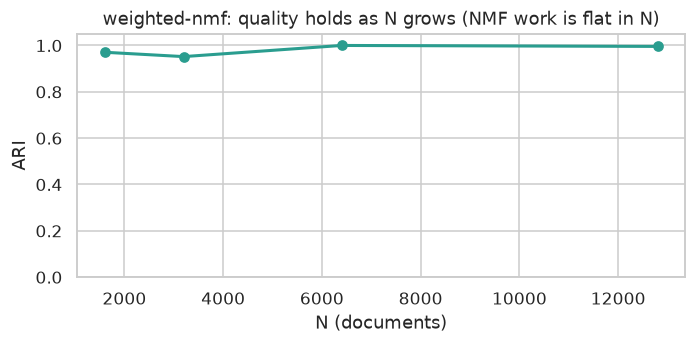

In [4]:
sizes = [400, 800, 1600, 3200]
curve = []
for per in sizes:
    Xn, yn, _ = topic_corpus(per, d, k, seed=1)
    lab = betula_cluster.fit_predict(
        Xn, k, method="kmeans", projection="weighted-nmf", projection_dim=8, **kw
    )
    curve.append(ari(yn, np.asarray(lab)))

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot([s * k for s in sizes], curve, "o-", lw=2, color="#2a9d8f")
ax.set(xlabel="N (documents)", ylabel="ARI", title="weighted-nmf: quality holds as N grows (NMF work is flat in N)", ylim=(0, 1.05))
fig.tight_layout()
plt.show()

## Nonnegative only — signed input is rejected, not shifted

NMF is undefined for signed values, and shifting `X - X.min()` would change angles and the cosine
geometry. The engine refuses signed data rather than silently corrupt it — for signed embeddings use
the **directional** heads (`vmf` / `spherical-kmeans`) or reduce with PCA / TruncatedSVD first.

In [5]:
try:
    betula_cluster.fit_predict(X - 1.0, k, method="kmeans", projection="weighted-nmf", projection_dim=8)
    print("no error (unexpected)")
except ValueError as e:
    print("rejected signed input:", str(e)[:80])

rejected signed input: projection='weighted-nmf' requires nonnegative data (X >= 0) — NMF is undefined 


**Takeaway.** For **nonnegative, additive** data, `projection="weighted-nmf"` learns interpretable
nonnegative parts and clusters their codes — but factorizes the `M ≪ N` leaf centroids, so NMF runs at
BETULA scale and bounded memory (point-level NMF cannot stream). It is an **opt-in reducer** for
nonnegative data only; for signed embeddings reach for `vmf` / `spherical-kmeans` or PCA / TruncatedSVD.
See the [Usage guide](../docs/USAGE.md) and
[`docs/MATH.md`](../docs/MATH.md#cf-weighted-nmf-for-nonnegative-data).